In [1]:
import sys
sys.path.insert(0, ".")

import os
import tempfile
import json
from pathlib import Path
from datasets import load_dataset
from tqdm.notebook import tqdm
from src.frame_extractor import FrameExtractor, ExtractionConfig

objc[45982]: Class AVFFrameReceiver is implemented in both /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x13a2b83a8) and /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x17ffb83a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[45982]: Class AVFAudioReceiver is implemented in both /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x13a2b83f8) and /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x17ffb83f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


In [2]:
config = ExtractionConfig(
    frames_per_segment=8,
    output_format="jpg",
    output_dir="output/frames",
    min_segment_duration=0.5,
)
extractor = FrameExtractor(config)

In [3]:
ds = load_dataset(
    "friedrichor/ActivityNet_Captions",
    split="train",
    streaming=True,
)

In [18]:
# Run in any notebook first
ds_full = load_dataset("friedrichor/ActivityNet_Captions", split="train", streaming=True)
count = sum(1 for _ in ds_full)
print(f"Total videos: {count}")

Total videos: 10009


In [14]:
import yt_dlp
import tempfile
import os

def get_youtube_id(video_field):
    """Extract YouTube ID from filename like 'v_QOlSCBRmfWY.mp4'"""
    stem = Path(video_field).stem   # 'v_QOlSCBRmfWY'
    return stem.lstrip("v_")        # 'QOlSCBRmfWY'

def download_video(youtube_id, output_path):
    """Download a YouTube video to output_path. Returns True if successful."""
    url = f"https://www.youtube.com/watch?v={youtube_id}"
    ydl_opts = {
        "format"  : "mp4[height<=480]/best[ext=mp4]/best",
        "outtmpl" : output_path,
        "quiet"   : True,
        "no_warnings": True,
    }
    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([url])
        return True
    except Exception as e:
        print(f"  [download error] {youtube_id}: {e}")
        return False

import uuid

def process_sample(sample, extractor):
    video_id   = sample["video_id"]
    timestamps = sample["timestamps"]
    sentences  = sample["sentences"]
    youtube_id = get_youtube_id(sample["video"])

    # Don't pre-create the file — just generate a path
    tmp_path = f"/tmp/{uuid.uuid4()}.mp4"

    success = download_video(youtube_id, tmp_path)
    if not success or not os.path.exists(tmp_path):
        print(f"  [skip] {video_id} — download failed")
        return None

    try:
        results = extractor.extract_from_video(
            video_path=tmp_path,
            video_id=video_id,
            timestamps=timestamps,
            sentences=sentences,
        )
        return results
    except Exception as e:
        print(f"  [error] {video_id}: {e}")
        return None
    finally:
        if os.path.exists(tmp_path):
            os.unlink(tmp_path)

In [ ]:
# sample = next(iter(ds))

# print(type(sample["video"]))
# print(sample["video"])

<class 'str'>
v_QOlSCBRmfWY.mp4


In [ ]:
# sample = next(iter(ds))

# print(f"Video ID    : {sample['video_id']}")
# print(f"Video field : {sample['video']}")
# print(f"YouTube ID  : {get_youtube_id(sample['video'])}")
# print(f"Segments    : {len(sample['timestamps'])}")

Video ID    : v_QOlSCBRmfWY
Video field : v_QOlSCBRmfWY.mp4
YouTube ID  : QOlSCBRmfWY
Segments    : 3


In [ ]:
# import tempfile
# import os
# import glob

# # Test the download in isolation
# with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as tmp:
#     tmp_path = tmp.name

# print(f"Expected path : {tmp_path}")

# success = download_video(get_youtube_id(sample["video"]), tmp_path)

# # Check what files actually exist near that path
# tmp_dir = os.path.dirname(tmp_path)
# tmp_stem = os.path.basename(tmp_path)
# matches = glob.glob(f"{tmp_dir}/{tmp_stem}*")
# print(f"Files found   : {matches}")
# print(f"Expected exists: {os.path.exists(tmp_path)}")

Expected path : /var/folders/yy/5xmm98ks22ndvhr1myh0x83c0000gn/T/tmptj4t9sem.mp4
Files found   : ['/var/folders/yy/5xmm98ks22ndvhr1myh0x83c0000gn/T/tmptj4t9sem.mp4']
Expected exists: True


In [ ]:
# import av

# print(f"File size: {os.path.getsize(tmp_path) / 1024 / 1024:.1f} MB")

# try:
#     with av.open(tmp_path) as container:
#         stream = container.streams.video[0]
#         duration = float(container.duration) / 1_000_000
#         fps = float(stream.average_rate)
#         print(f"Duration : {duration:.2f}s")
#         print(f"FPS      : {fps:.2f}")
#         print(f"Codec    : {stream.codec_context.name}")
# except Exception as e:
#     print(f"PyAV error: {e}")

File size: 0.0 MB
PyAV error: [Errno 1094995529] Invalid data found when processing input: '/var/folders/yy/5xmm98ks22ndvhr1myh0x83c0000gn/T/tmptj4t9sem.mp4'


In [ ]:
# # Instead of NamedTemporaryFile, just generate a path
# import uuid
# tmp_path = f"/tmp/{uuid.uuid4()}.mp4"
# download_video(get_youtube_id(sample["video"]), tmp_path)
# print(f"File size: {os.path.getsize(tmp_path) / 1024 / 1024:.1f} MB")

File size: 3.1 MB                                        


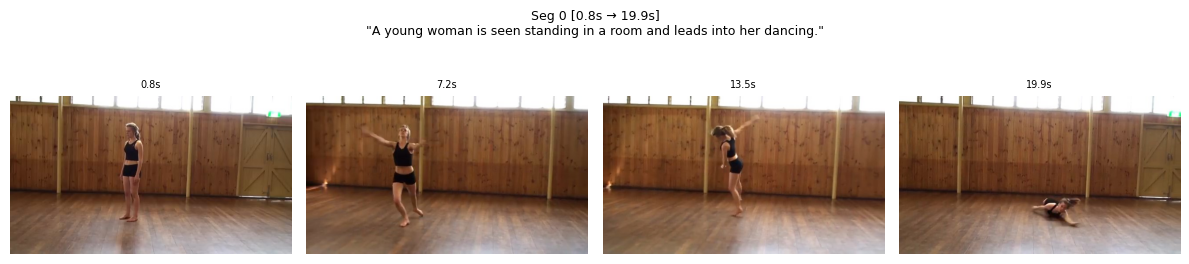

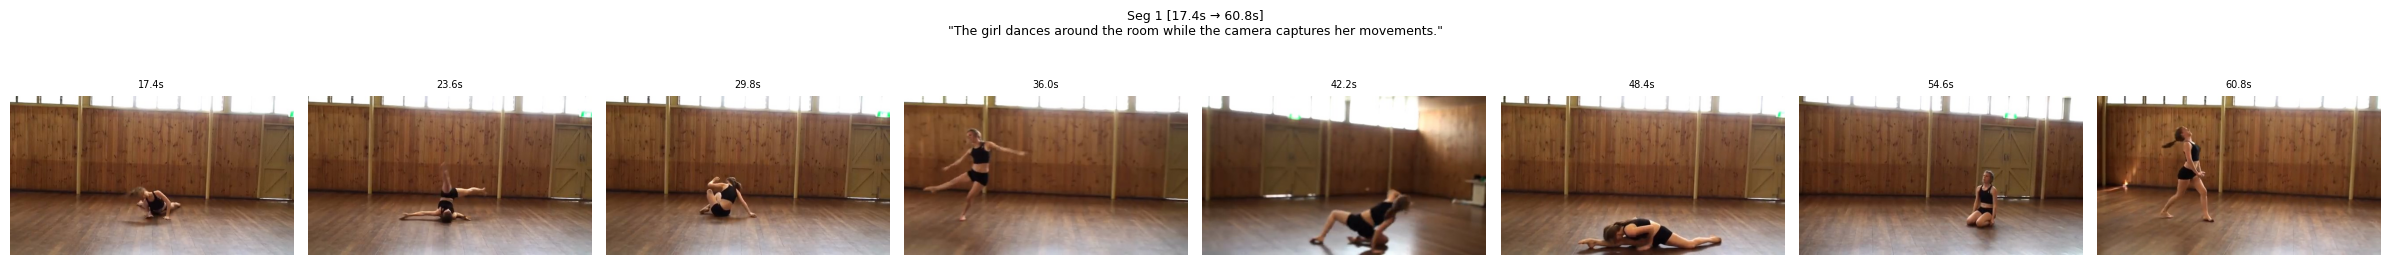

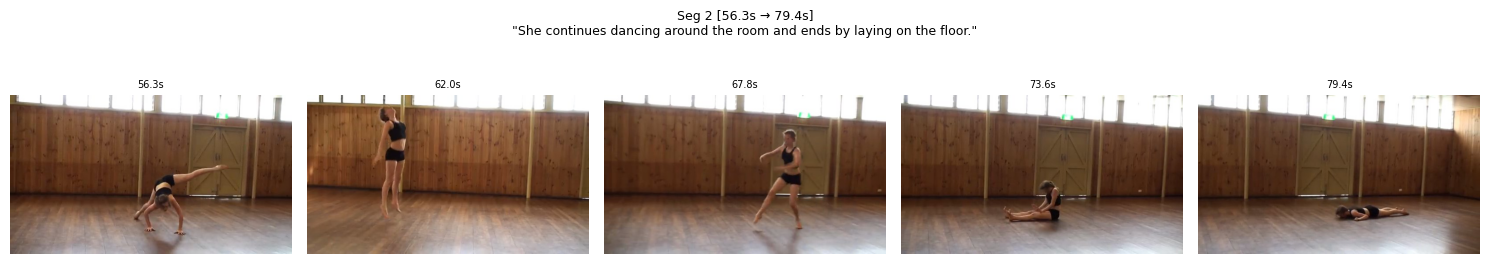

In [15]:
results = process_sample(sample, extractor)

if results:
    for seg in results:
        n = len(seg.frame_paths)
        fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
        if n == 1:
            axes = [axes]
        fig.suptitle(
            f'Seg {seg.segment_index} [{seg.timestamp_start:.1f}s → {seg.timestamp_end:.1f}s]\n"{seg.sentence}"',
            fontsize=9
        )
        for ax, path, ft in zip(axes, seg.frame_paths, seg.frame_timestamps):
            ax.imshow(mpimg.imread(path))
            ax.set_title(f"{ft:.1f}s", fontsize=7)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

In [19]:
MANIFEST_PATH = Path("output/manifest.jsonl")
MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
N_VIDEOS = 500

processed = 0
skipped   = 0

with open(MANIFEST_PATH, "a") as manifest:
    for sample in tqdm(ds, total=N_VIDEOS):
        results = process_sample(sample, extractor)

        if results is None:
            skipped += 1
        else:
            processed += 1
            entry = {
                "video_id": sample["video_id"],
                "caption" : sample["caption"],
                "segments": [
                    {
                        "segment_index"   : seg.segment_index,
                        "timestamp_start" : seg.timestamp_start,
                        "timestamp_end"   : seg.timestamp_end,
                        "sentence"        : seg.sentence,
                        "frame_paths"     : seg.frame_paths,
                        "frame_timestamps": seg.frame_timestamps,
                    }
                    for seg in results
                ]
            }
            manifest.write(json.dumps(entry) + "\n")

        if processed + skipped >= N_VIDEOS:
            break

print(f"\nDone — processed: {processed}  skipped: {skipped}")

  0%|          | 0/500 [00:00<?, ?it/s]

ERROR: [youtube] ehGHCYKzyZ8: Video unavailable


  [download error] ehGHCYKzyZ8: ERROR: [youtube] ehGHCYKzyZ8: Video unavailable
  [skip] v_ehGHCYKzyZ8 — download failed


ERROR: [youtube] LNKdVrX_0Fg: This video is not available


  [download error] LNKdVrX_0Fg: ERROR: [youtube] LNKdVrX_0Fg: This video is not available
  [skip] v_LNKdVrX_0Fg — download failed


...

  [download error] WQAVlmS5IWs: ERROR: [youtube] WQAVlmS5IWs: Video unavailable
  [skip] v_WQAVlmS5IWs — download failed


ERROR: [youtube] o5j6N8O6HS4: Video unavailable


  [download error] o5j6N8O6HS4: ERROR: [youtube] o5j6N8O6HS4: Video unavailable
  [skip] v_o5j6N8O6HS4 — download failed


ERROR: [youtube] ZazjI26IQUo: Video unavailable. This video is no longer available because the YouTube account associated with this video has been terminated.


  [download error] ZazjI26IQUo: ERROR: [youtube] ZazjI26IQUo: Video unavailable. This video is no longer available because the YouTube account associated with this video has been terminated.
  [skip] v_ZazjI26IQUo — download failed
                                                           
Done — processed: 388  skipped: 112


In [20]:
# Cell 8 — auto-trigger descriptions after pipeline finishes
import subprocess
subprocess.run([
    "jupyter", "nbconvert", "--to", "notebook",
    "--execute", "04_frame_descriptions.ipynb",
    "--output", "04_frame_descriptions_executed.ipynb"
])
print("Descriptions done ✅")

Descriptions done ✅


usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.


In [21]:
# Check manifest
import json
from pathlib import Path

MANIFEST_PATH = Path("output/manifest.jsonl")

entries = []
with open(MANIFEST_PATH) as f:
    for line in f:
        entries.append(json.loads(line))

total_segments = sum(len(e["segments"]) for e in entries)
total_frames   = sum(len(s["frame_paths"]) for e in entries for s in e["segments"])

print(f"Videos processed : {len(entries)}")
print(f"Total segments   : {total_segments}")
print(f"Total frames     : {total_frames}")

Videos processed : 397
Total segments   : 1505
Total frames     : 7013


In [22]:
from pathlib import Path
p = Path("output/descriptions.jsonl")
print(f"Exists : {p.exists()}")
if p.exists():
    print(f"Size   : {p.stat().st_size / 1024 / 1024:.1f} MB")
    # Count lines
    with open(p) as f:
        lines = sum(1 for _ in f)
    print(f"Entries: {lines}")

Exists : True
Size   : 0.0 MB
Entries: 9
